# Banka Kredi Risk Analizi ve Batık Tahmin Modeli

### Bu projede banka müşterilerinin demografik ve finansal verilerini kullanarak kredi batırma riskini analiz ettim.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Python dünyasın hoş geldiniz sayın Onlay GÖRÜCÜ")

Python dünyasın hoş geldiniz sayın Onlay GÖRÜCÜ


In [5]:
df = pd.read_csv("bankloans_calisma.csv", sep=";")
df.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,47,1,31,9,136,23.1,14.23,17.18,1.0
1,47,1,31,8,253,7.2,9.31,8.91,0.0
2,51,2,31,14,249,7.8,4.27,15.15,0.0
3,48,2,30,14,148,7.2,3.97,6.68,0.0
4,48,1,30,8,101,6.4,1.87,4.59,0.0


In [6]:
dusuk_gelirli = df[(df['income'] < 30) & (df['debtinc'] > 15) & (df['default'].notnull())]
kisi_sayisi = len(dusuk_gelirli)
batirma_riski= dusuk_gelirli['default'].mean() * 100
print(f"Düşük Gelirli ve Yüksek Borçlu Kişi Sayısı: {kisi_sayisi}")
print(f"Batırma Riski: %{batirma_riski:.1f}")

Düşük Gelirli ve Yüksek Borçlu Kişi Sayısı: 58
Batırma Riski: %62.1


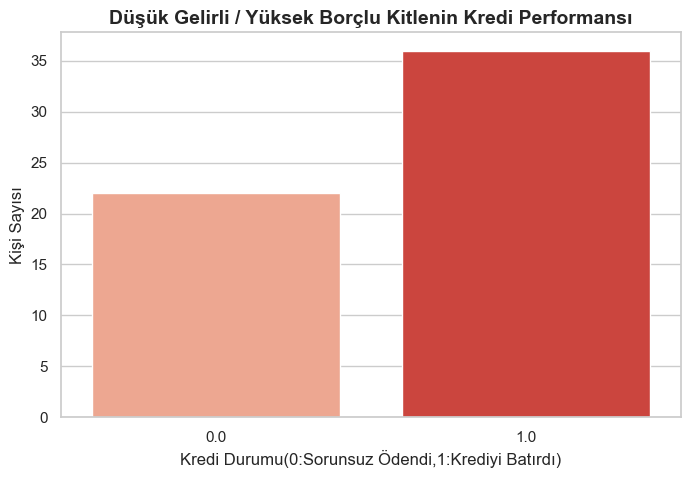

In [7]:
plt.figure(figsize=(8,5))
sns.set_theme(style="whitegrid")
# Düşük gelirli grubun batırma durumunu (default) çubuk grafiğe döküyoruz
# Tehlikeyi vurgulamak için kırmızı tonlarında bir renk paleti (Reds) seçtik
sns.countplot(data=dusuk_gelirli, x='default', hue='default', palette='Reds', legend=False)
# Grafiğe anlaşılır başlıklar ekleyelim
plt.title('Düşük Gelirli / Yüksek Borçlu Kitlenin Kredi Performansı', fontsize=14,fontweight='bold')
plt.xlabel('Kredi Durumu(0:Sorunsuz Ödendi,1:Krediyi Batırdı)',fontsize=12)
plt.ylabel('Kişi Sayısı',fontsize=12)

plt.show()

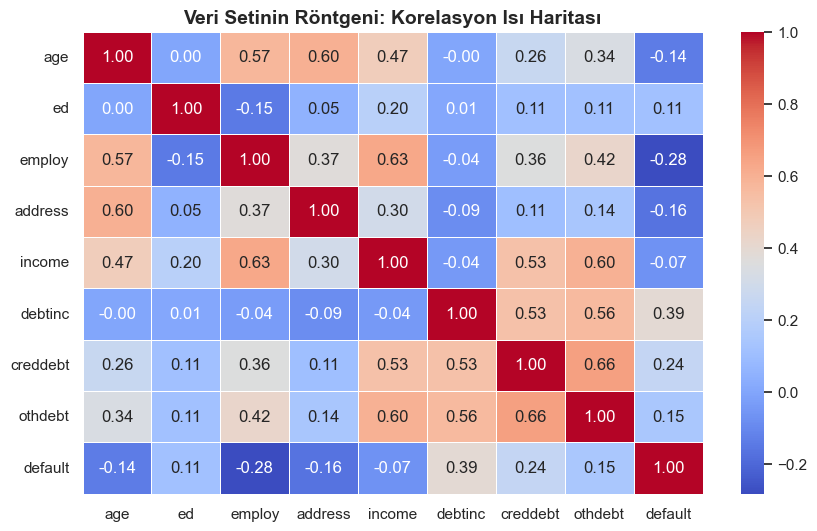

In [8]:
plt.figure(figsize=(10,6))
# df.corr() ile tüm değişkenlerin birbiriyle olan matematiksel ilişkisini hesaplatıp ısı haritasına döküyoruz
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Veri Setinin Röntgeni: Korelasyon Isı Haritası', fontsize=14, fontweight='bold')
plt.show()

### Korelasyon ısı haritası sonucunda, borç/gelir oranının (0.39) en büyük risk faktörü olduğunu, uzun süreli istihdamın ise (-0.28) riski düşürdüğünü tespit ettim.

In [9]:
from sklearn.model_selection import train_test_split
# 1. Veri Temizliği: Akıbeti belli olmayanları (default sütunu boş olanları) eğitimden çıkarıyoruz
df_model = df.dropna(subset=['default']).copy()
# 2. Hedef (y) ve Özellikleri (X) Belirleme
# Yapay zekaya "Buna bakarak (X), bunu tahmin et (y)" diyeceğiz.
X = df_model.drop(['default'], axis=1) # Default hariç tüm sütunlar (yaş, gelir vb.) bizim ipuçlarımız
y = df_model['default'] # Tahmin etmeye çalıştığımız asıl hedef (0 veya 1)
# 3. Veriyi Eğitim (%80) ve Test (%20) olarak ikiye bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Yapay zekanın eğitim için kullanacağı kişi sayısı: {len(X_train)}")
print(f"Modelin performansını test edeceğimiz kişi sayısı: {len(X_test)}")

Yapay zekanın eğitim için kullanacağı kişi sayısı: 560
Modelin performansını test edeceğimiz kişi sayısı: 140


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Modeli Yaratma (Yapay zekanın boş beynini çağırıyoruz)
# max_iter=1000 yazıyoruz ki hesaplama yaparken yarı yolda nefesi kesilmesin
model = LogisticRegression(max_iter=1000)

# 2. Eğitim Aşaması (Ders Çalışma)
# fit() komutu "öğren" demektir. X_train (özellikler) ve y_train (gerçek sonuçlar) ile modeli eğitiyoruz.
model.fit(X_train, y_train)

# 3. Test Aşaması (Sınav)
# predict() komutu "tahmin et" demektir. Modelden, hiç görmediği X_test verilerine bakarak tahmin yapmasını istiyoruz.
tahminler = model.predict(X_test)

# 4. Karne Zamanı! (Gerçek sonuçlar olan y_test ile modelin tahminlerini karşılaştırıyoruz)
basari_orani = accuracy_score(y_test, tahminler) * 100

print(f"Yapay Zekanın Başarı Oranı: %{basari_orani:.1f}\n")
print("Detaylı Analiz Raporu:")
print(classification_report(y_test, tahminler))

Yapay Zekanın Başarı Oranı: %80.0

Detaylı Analiz Raporu:
              precision    recall  f1-score   support

         0.0       0.83      0.92      0.87       104
         1.0       0.67      0.44      0.53        36

    accuracy                           0.80       140
   macro avg       0.75      0.68      0.70       140
weighted avg       0.79      0.80      0.79       140



In [12]:
# Modeli bu sefer 'balanced' (dengeli) parametresiyle baştan kuruyoruz
model_dengeli = LogisticRegression(class_weight='balanced', max_iter=1000)

# Modeli eğitme
model_dengeli.fit(X_train, y_train)

# Yeni tahminler
tahminler_dengeli = model_dengeli.predict(X_test)

# Yeni Karne
basari_orani_dengeli = accuracy_score(y_test, tahminler_dengeli) * 100

print(f"Dengelenmiş Model Başarı Oranı: %{basari_orani_dengeli:.1f}\n")
print("Yeni Detaylı Analiz Raporu:")
print(classification_report(y_test, tahminler_dengeli))

Dengelenmiş Model Başarı Oranı: %79.3

Yeni Detaylı Analiz Raporu:
              precision    recall  f1-score   support

         0.0       0.91      0.80      0.85       104
         1.0       0.57      0.78      0.66        36

    accuracy                           0.79       140
   macro avg       0.74      0.79      0.76       140
weighted avg       0.82      0.79      0.80       140



### Model başlangıçta genel başarıyı yüksek tutmak için riskli müşterileri gözden kaçırıyordu. class_weight='balanced' parametresi ile veri dengesizliğini çözerek, batık müşterileri yakalama oranımı (Recall) %44'ten %78'e çıkardım ve bankanın olası zararını minimize ettim.